In [2]:
# 1. THE IMPORTS (Tell Python which tools we need)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df = pd.read_csv("netflix_reviews_10000.csv")

print(f"Dataset loaded! We have {len(df)} reviews ready.")
print(df.head()) # Shows the first 5 rows to make sure it looks right


Dataset loaded! We have 10000 reviews ready.
                               reviewId              userName  \
0  42e70c5a-6965-422c-897b-42986b3f974c          Nicholai Luy   
1  40bc4d56-18f4-4948-9756-b291408d43ea    Richard Gere-Imets   
2  60e0d76b-a10c-4aaf-af1d-0fcade7bc8fd  2K21_EE_105 Dikshant   
3  428dfe19-aa01-4075-92a0-dac43899aabf          saberspecter   
4  66ea2909-19af-4e08-9ed6-2ee366befeee           Jim Darnley   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a/ACg8oc...   
1  https://play-lh.googleusercontent.com/a/ACg8oc...   
2  https://play-lh.googleusercontent.com/a-/ALV-U...   
3  https://play-lh.googleusercontent.com/a-/ALV-U...   
4  https://play-lh.googleusercontent.com/a-/ALV-U...   

                                             content  score  thumbsUpCount  \
0                                               goid      5              0   
1  Netflix is amazing. It offers the same quality...      5            

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("netflix_reviews_10000.csv")

X = df['content'].astype(str) 
y = df['score'] 

# Split the data (80% to learn, 20% to test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Turn Text into Numbers (Vectorization)
vectorizer = CountVectorizer(stop_words='english')
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

# Train the Model
model = MultinomialNB()
model.fit(X_train_counts, y_train)

# Test the Model
predictions = model.predict(X_test_counts)

print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")
print("\nDetailed Report:\n", classification_report(y_test, predictions))


Accuracy: 72.80%

Detailed Report:
               precision    recall  f1-score   support

           1       0.71      0.90      0.80       776
           2       0.20      0.02      0.04       122
           3       0.17      0.01      0.01       128
           4       0.00      0.00      0.00       148
           5       0.76      0.91      0.83       826

    accuracy                           0.73      2000
   macro avg       0.37      0.37      0.34      2000
weighted avg       0.61      0.73      0.65      2000



In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Convert text to numbers using TF-IDF 

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df['content'].astype(str))

# Tell the AI to find distinct groups (clusters)
true_k = 3
model = KMeans(n_clusters=true_k, init='k-means++', max_iter=100, n_init=1)
model.fit(X)

# Add the Cluster ID back to your original DataFrame
df['cluster'] = model.labels_

# See what's inside each cluster
print("Top terms per cluster:")
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(true_k):
    print(f"\nCluster {i}:")
    for ind in order_centroids[i, :10]: # Show top 10 words for this group
        print(f' {terms[ind]}', end='')
    print()


Top terms per cluster:

Cluster 0:
 movies series watch netflix shows app good love best great

Cluster 1:
 good app netflix love nice best great watch like movie

Cluster 2:
 lots movies shows good great easy app issues choice use


In [5]:
# See the average star rating for each cluster
print(df.groupby('cluster')['score'].mean())


cluster
0    3.770810
1    2.944396
2    4.086957
Name: score, dtype: float64


In [6]:
# Re-run with 'max_df' to ignore words that appear in more than 50% of reviews
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.5) 


In [7]:
print(df['cluster'].value_counts())


cluster
1    9100
0     877
2      23
Name: count, dtype: int64


In [8]:
# Updated Vectorizer to find REAL topics
vectorizer = TfidfVectorizer(
    stop_words='english', 
    max_df=0.5,      # Ignore words that are TOO common
    min_df=5,        # Ignore words that only appear once or twice
    ngram_range=(1,2) # Look for phrases like "customer service" or "waste money"
)


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# HE NOISE FILTER
# max_df=0.4 means "ignore words that appear in more than 40% of reviews" (like 'netflix')
# ngram_range=(1,2) means "look for phrases like 'price hike' or 'app crash'"
vectorizer = TfidfVectorizer(
    stop_words='english', 
    max_df=0.4, 
    min_df=2, 
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df['content'].astype(str))

# CLUSTERING (Let's stick with 3 for now)
model = KMeans(n_clusters=3, random_state=42)
model.fit(X)
df['cluster'] = model.labels_

# SHOW THE "REAL" TOPICS
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

print("--- NEW DISCOVERED TOPICS ---")
for i in range(3):
    print(f"\nGroup {i} (Top Phrases):")
    # Show top 15 words/phrases to see the 'theme'
    print(", ".join([terms[ind] for ind in order_centroids[i, :15]]))


--- NEW DISCOVERED TOPICS ---

Group 0 (Top Phrases):
app, netflix, nice, movies, watch, good, bad, like, shows, movie, just, excellent, best, series, phone

Group 1 (Top Phrases):
good, good app, app, good good, excellent, amazing, video, want, nice, movie, great, best, glitching lot, glitches, god netflix

Group 2 (Top Phrases):
love, great, best, app, love netflix, best app, love app, netflix, great app, movies, just love, love watching, shows, good love, app love


In [44]:
# ADD CUSTOM "IGNORE" WORDS
# We are banning the "fluff" words that appear in all groups
custom_stop_words = ['app', 'netflix', 'good', 'love', 'best', 'great', 'nice', 'movie', 'movies', 'watch', 'shows', 'series', 'just', 'like', 'excellent', 'amazing']
from sklearn.feature_extraction import text
final_stop_words = text.ENGLISH_STOP_WORDS.union(custom_stop_words)

# INCREASE THE "NOISE FILTER"
# max_df=0.2 means "ignore words that appear in more than 20% of reviews"
vectorizer = TfidfVectorizer(
    stop_words=list(final_stop_words), 
    max_df=0.2, 
    min_df=10, 
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df['content'].astype(str))

# INCREASE THE NUMBER OF CLUSTERS
model = KMeans(n_clusters=5, random_state=42)
model.fit(X)
df['cluster'] = model.labels_

# 4. SHOW THE RESULTS
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(5):
    print(f"\nGroup {i}: {', '.join([terms[ind] for ind in order_centroids[i, :10]])}")



Group 0: users, says, watching, zero, force, forced, forces, forcing, forever, form

Group 1: streaming, quality, service, content, high, high quality, streaming service, video, smooth, platform

Group 2: bad, tv, don, phone, use, watching, time, want, working, account

Group 3: bring, friends, bring friends, casting, supernatural, anime, guys, chromecast, mode, mean

Group 4: fantastic, chill, super, performance, selection, films, plays, recently, greed, ok


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import numpy as np
import pandas as pd

# Load the file you saved in the previous notebook
df = pd.read_csv("netflix_reviews_10000.csv")

In [5]:
vectorizer = TfidfVectorizer(
    stop_words='english', 
    max_df=0.5, 
    min_df=5, 
    ngram_range=(1, 2)
)
X = vectorizer.fit_transform(df['content'].astype(str))

#  MODEL: Extract 5 clear topics
nmf_model = NMF(n_components=5, random_state=42, init='nndsvd')
W = nmf_model.fit_transform(X) # Document-topic matrix
H = nmf_model.components_      # Topic-word matrix

# IDENTIFY: Get the top words for each "Bucket"
words = np.array(vectorizer.get_feature_names_out())
for i, topic in enumerate(H):
    top_words = [words[j] for j in topic.argsort()[-10:]]
    print(f"Bucket {i}: {', '.join(top_words)}")


df['topic_bucket'] = W.argmax(axis=1)

Bucket 0: good good, good experience, really good, good shows, app, movies, app good, good movies, good app, good
Bucket 1: application, aap, nice movies, easy, apps, nice good, movies, app, nice app, nice
Bucket 2: just love, just, things, love watching, shows, movies, love app, netflix, love netflix, love
Bucket 3: bad, movie, like, good app, watch, movies, netflix, best app, best, app
Bucket 4: great experience, netflix great, app movies, series, great movies, app, shows, movies, great app, great


In [6]:
# Create a dictionary to map numbers to human-readable labels
# Adjust these labels based on what YOUR bucket words actually were!
topic_labels = {
    0: "Technical & App Performance",
    1: "Pricing & Subscription",
    2: "Content & User Experience",
    3: "Account & Login Issues"
}

# Apply the labels to your DataFrame
df['topic_name'] = df['topic_bucket'].map(topic_labels)

In [8]:
# Create a summary table
summary_table = df.groupby('topic_name').agg({
    'content': 'count',      # Number of reviews
    'score': 'mean'         # Average star rating
    # 'confidence' column was removed as it doesn't exist in the DataFrame
}).rename(columns={'content': 'Review Count', 'score': 'Average Rating'})

# Sort it to see the biggest problems at the top
summary_table = summary_table.sort_values(by='Review Count', ascending=False)

print(summary_table)

                             Review Count  Average Rating
topic_name                                               
Account & Login Issues               7069        2.485500
Technical & App Performance          1515        4.147757
Content & User Experience             599        4.514190
Pricing & Subscription                358        4.578212


In [9]:
# First create the basic summary table
summary_table = df.groupby('topic_name').agg({
    'content': 'count',      # Number of reviews
    'score': 'mean'         # Average star rating
}).rename(columns={'content': 'Review Count', 'score': 'Average Rating'})

# Sort it to see the biggest problems at the top
summary_table = summary_table.sort_values(by='Review Count', ascending=False)

# Function to get sample reviews for each topic
def get_sample_reviews(topic):
    # Get reviews for this topic (assuming 'review_text' contains the actual reviews)
    topic_reviews = df[df['topic_name'] == topic]['review_text'].sample(min(3, len(df[df['topic_name'] == topic])))
    # Return as a formatted string
    return '\n'.join(topic_reviews.tolist())

# Add sample reviews to the summary table
summary_table['Sample Reviews'] = summary_table.index.map(get_sample_reviews)

print(summary_table)

KeyError: 'review_text'

In [10]:
# create the summary table
summary_table = df.groupby('topic_name').agg({
    'content': 'count',      # Number of reviews
    'score': 'mean'         # Average star rating
}).rename(columns={'content': 'Review Count', 'score': 'Average Rating'})

# Sort it to see the biggest problems at the top
summary_table = summary_table.sort_values(by='Review Count', ascending=False)

# Function to get sample reviews for each topic
def get_sample_reviews(topic):
    # Get reviews for this topic (using 'content' column instead of 'review_text')
    topic_reviews = df[df['topic_name'] == topic]['content'].sample(min(3, len(df[df['topic_name'] == topic])))
    # Return as a formatted string
    return '\n'.join(topic_reviews.tolist())
    
summary_table['Sample Reviews'] = summary_table.index.map(get_sample_reviews)

print(summary_table)

                             Review Count  Average Rating  \
topic_name                                                  
Account & Login Issues               7069        2.485500   
Technical & App Performance          1515        4.147757   
Content & User Experience             599        4.514190   
Pricing & Subscription                358        4.578212   

                                                                Sample Reviews  
topic_name                                                                      
Account & Login Issues       YOU CANT EVEN LOAD\nZero estrelas para o upgra...  
Technical & App Performance  eww :3\ngood\nIt's good i don't know why peopl...  
Content & User Experience    I love Netflix BUT..... please add all seasons...  
Pricing & Subscription                                      Nice\nnice 👍\nNice  


In [17]:
import pandas as pd

# Reset index so topic_name becomes a column
export_df = summary_table.reset_index()

# Rename columns to your preferred names
export_df = export_df.rename(columns={
    'topic_name': 'Topic Name',
    'Review Count': 'Review Count',
    'Average Rating': 'Rating',
    'Sample Reviews': 'Sample Reviews'
})

# Reorder columns
export_df = export_df[['Topic Name', 'Review Count', 'Sample Reviews', 'Rating']]

# Round rating to 2 decimal places
export_df['Rating'] = export_df['Rating'].round(2)

# Export to CSV
export_df.to_csv('topic_summary.csv', index=False)

print("CSV saved as topic_summary.csv")
print(export_df.head())

CSV saved as topic_summary.csv
                    Topic Name  Review Count  \
0       Account & Login Issues          7069   
1  Technical & App Performance          1515   
2    Content & User Experience           599   
3       Pricing & Subscription           358   

                                      Sample Reviews  Rating  
0  3 minutes ads every 10 minutes its outrageous\...    2.49  
1  good\njunk not too good anymore not a lot of o...    4.15  
2       love it\nI love it\ni love Netflix as always    4.51  
3  nice to Netflix\nNice to binge....... Good for...    4.58  


In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   reviewId              10000 non-null  object 
 1   userName              10000 non-null  object 
 2   userImage             10000 non-null  object 
 3   content               9999 non-null   object 
 4   score                 10000 non-null  int64  
 5   thumbsUpCount         10000 non-null  int64  
 6   reviewCreatedVersion  6996 non-null   object 
 7   at                    10000 non-null  object 
 8   replyContent          0 non-null      float64
 9   repliedAt             0 non-null      float64
 10  appVersion            6996 non-null   object 
 11  topic_bucket          10000 non-null  int64  
 12  topic_name            9542 non-null   object 
dtypes: float64(2), int64(3), object(8)
memory usage: 1015.8+ KB
None


In [22]:
!pip install sentence-transformers

In [25]:
!pip install sentence-transformers openai scikit-learn

In [29]:
import pandas as pd
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
from transformers import pipeline
import numpy as np

df = pd.read_csv("netflix_reviews_10000.csv")

# Step 1: Embed reviews (free, runs locally)
print("Embedding reviews...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedder.encode(df['content'].astype(str).tolist(), show_progress_bar=True)

# Step 2: Cluster
N_CLUSTERS = 15
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42)
df['cluster_id'] = kmeans.fit_predict(embeddings)

# Step 3: Auto-label topics using TF-IDF (finds most important keywords per cluster)
from sklearn.feature_extraction.text import TfidfVectorizer

def get_cluster_topic(cluster_id):
    texts = df[df['cluster_id'] == cluster_id]['content'].astype(str).tolist()
    tfidf = TfidfVectorizer(max_features=5, stop_words='english')
    tfidf.fit(texts)
    keywords = tfidf.get_feature_names_out()
    return " / ".join(keywords)

# Step 4: Sentiment using free HuggingFace model
print("Loading sentiment model...")
sentiment_pipeline = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")

def get_cluster_sentiment(cluster_id):
    samples = df[df['cluster_id'] == cluster_id]['content'].astype(str).sample(min(10, len(df[df['cluster_id'] == cluster_id]))).tolist()
    # Truncate to 512 chars (model limit)
    samples = [s[:512] for s in samples]
    results = sentiment_pipeline(samples)
    labels = [r['label'] for r in results]
    # Return most common sentiment
    return max(set(labels), key=labels.count)

# Step 5: Label all clusters
print("Labeling clusters...")
cluster_labels = {}
for cid in range(N_CLUSTERS):
    topic = get_cluster_topic(cid)
    sentiment = get_cluster_sentiment(cid)
    cluster_labels[cid] = {"topic": topic, "sentiment": sentiment}
    print(f"Cluster {cid}: {topic} | {sentiment}")

# Step 6: Map back and export
df['topic_name'] = df['cluster_id'].map(lambda x: cluster_labels[x]['topic'])
df['sentiment'] = df['cluster_id'].map(lambda x: cluster_labels[x]['sentiment'])

df.to_csv("netflix_reviews_clustered.csv", index=False)
print("Done!")

Embedding reviews...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Loading sentiment model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Labeling clusters...
Cluster 0: good / great / like / love / nice | positive
Cluster 1: good / love / movie / movies / watch | positive
Cluster 2: app / love / movies / netflix / watch | positive
Cluster 3: app / best / good / movies / watch | positive
Cluster 4: amazing / awesome / excellent / great / nice | positive
Cluster 5: app / best / good / love / nice | positive
Cluster 6: fine / good / nice / ok / okay | positive
Cluster 7: app / brightness / phone / tv / watch | negative
Cluster 8: app / keeps / open / phone / working | negative
Cluster 9: like / netflix / series / shows / watch | negative
Cluster 10: ads / app / pay / payment / subscription | negative
Cluster 11: app / hai / hindi / language / netflix | neutral
Cluster 12: account / app / log / login / sign | negative
Cluster 13: account / app / netflix / phone / watch | negative
Cluster 14: bad / best / easy / experience / good | neutral
Done!


In [30]:
# Make a clean summary table
summary = []
for cid in range(N_CLUSTERS):
    cluster_df = df[df['cluster_id'] == cid]
    summary.append({
        'Cluster': cid,
        'Topic Keywords': cluster_labels[cid]['topic'],
        'Sentiment': cluster_labels[cid]['sentiment'],
        'Review Count': len(cluster_df),
        'Sample Review 1': cluster_df['content'].iloc[0][:100] if len(cluster_df) > 0 else '',
        'Sample Review 2': cluster_df['content'].iloc[1][:100] if len(cluster_df) > 1 else '',
        'Sample Review 3': cluster_df['content'].iloc[2][:100] if len(cluster_df) > 2 else '',
    })

summary_df = pd.DataFrame(summary).sort_values('Review Count', ascending=False)
print(summary_df[['Cluster', 'Topic Keywords', 'Sentiment', 'Review Count']].to_string(index=False))

# Export full summary
summary_df.to_csv("netflix_cluster_summary.csv", index=False)
print("\nSaved to netflix_cluster_summary.csv")

 Cluster                               Topic Keywords Sentiment  Review Count
      14        bad / best / easy / experience / good   neutral          1175
      13      account / app / netflix / phone / watch  negative           869
       7        app / brightness / phone / tv / watch  negative           863
       2        app / love / movies / netflix / watch  positive           851
       9      like / netflix / series / shows / watch  negative           749
       6               fine / good / nice / ok / okay  positive           719
      10     ads / app / pay / payment / subscription  negative           690
       8         app / keeps / open / phone / working  negative           654
       5              app / best / good / love / nice  positive           630
       3           app / best / good / movies / watch  positive           551
      11       app / hai / hindi / language / netflix   neutral           536
       1         good / love / movie / movies / watch  positive 

In [37]:
!pip install transformers torch

In [ ]:
import requests

def label_cluster_with_ollama(cluster_id):
    samples = df[df['cluster_id'] == cluster_id]['content'].astype(str).sample(
        min(10, len(df[df['cluster_id'] == cluster_id]))
    ).tolist()
    sample_text = "\n---\n".join(samples)
    
    response = requests.post("http://localhost:11434/api/generate", json={
        "model": "llama3.2",
        "prompt": f"""Here are Netflix app reviews grouped together:

{sample_text}

Give this group:
1. A clear topic name (3-4 words max, like "Login Issues" or "Video Quality Problems")
2. Overall sentiment: Positive / Negative / Mixed

Respond ONLY in this format:
Topic: <topic name>
Sentiment: <sentiment>""",
        "stream": False
    })
    
    result = response.json()['response'].strip().split("\n")
    topic = result[0].replace("Topic:", "").strip()
    sentiment = result[1].replace("Sentiment:", "").strip()
    return topic, sentiment

for cid in range(N_CLUSTERS):
    topic, sentiment = label_cluster_with_ollama(cid)
    cluster_labels[cid] = {"topic": topic, "sentiment": sentiment}
    print(f"Cluster {cid}: {topic} | {sentiment}")

df['topic_name'] = df['cluster_id'].map(lambda x: cluster_labels[x]['topic'])
df['sentiment'] = df['cluster_id'].map(lambda x: cluster_labels[x]['sentiment'])

df.to_csv("netflix_reviews_clustered.csv", index=False)
print("Done!")

In [40]:
import requests

def label_cluster_with_ollama(cluster_id):
    samples = df[df['cluster_id'] == cluster_id]['content'].astype(str).sample(
        min(10, len(df[df['cluster_id'] == cluster_id]))
    ).tolist()
    sample_text = "\n---\n".join(samples)
    
    response = requests.post("http://localhost:11434/api/generate", json={
        "model": "llama3.2",
        "prompt": f"""Here are Netflix app reviews grouped together:

{sample_text}

Give this group:
1. A clear topic name (3-4 words max, like "Login Issues" or "Video Quality Problems")
2. Overall sentiment: Positive / Negative / Mixed

Respond ONLY in this format:
Topic: <topic name>
Sentiment: <sentiment>""",
        "stream": False
    })
    
    result = response.json()['response'].strip().split("\n")
    topic = result[0].replace("Topic:", "").strip()
    sentiment = result[1].replace("Sentiment:", "").strip()
    return topic, sentiment

for cid in range(N_CLUSTERS):
    topic, sentiment = label_cluster_with_ollama(cid)
    cluster_labels[cid] = {"topic": topic, "sentiment": sentiment}
    print(f"Cluster {cid}: {topic} | {sentiment}")

df['topic_name'] = df['cluster_id'].map(lambda x: cluster_labels[x]['topic'])
df['sentiment'] = df['cluster_id'].map(lambda x: cluster_labels[x]['sentiment'])

df.to_csv("netflix_reviews_clustered.csv", index=False)
print("Done!")

Cluster 0: Netflix App Experience | Positive
Cluster 1: Anime and Content Availability | Mixed
Cluster 2: Netflix User Reviews | Positive
Cluster 3: Netflix App Reviews | Mixed
Cluster 4: App Stability and Performance | Positive
Cluster 5: Netflix App User Reviews | Positive
Cluster 6: Netflix App Performance | Positive
Cluster 7: Video and Sound Issues | Negative
Cluster 8: Netflix App Bugs | Negative
Cluster 9: Netflix User Complaints | Negative
Cluster 10: Netflix App Reviews | Mixed
Cluster 11: Poor Netflix App Reviews | Negative
Cluster 12: Netflix App Bugs and Issues | Negative
Cluster 13: Netflix App Issues | Negative
Cluster 14: Random Netflix App Reviews | Mixed
Done!


In [41]:
# Count, percentage, and confidence per cluster
total_reviews = len(df)

summary = []
for cid in range(N_CLUSTERS):
    cluster_df = df[df['cluster_id'] == cid]
    
    # Count & percentage
    count = len(cluster_df)
    percentage = (count / total_reviews) * 100
    
    # Confidence = average distance to cluster center (lower = tighter/more confident)
    cluster_center = kmeans.cluster_centers_[cid]
    cluster_embeddings = embeddings[df['cluster_id'] == cid]
    distances = np.linalg.norm(cluster_embeddings - cluster_center, axis=1)
    avg_distance = distances.mean()
    
    # Normalize confidence to 0-100% (inverse of distance)
    confidence = 1 / (1 + avg_distance) * 100

    summary.append({
        'Cluster': cid,
        'Topic': cluster_labels[cid]['topic'],
        'Sentiment': cluster_labels[cid]['sentiment'],
        'Review Count': count,
        'Percentage (%)': round(percentage, 2),
        'Confidence (%)': round(confidence, 2)
    })

summary_df = pd.DataFrame(summary).sort_values('Review Count', ascending=False)
print(summary_df.to_string(index=False))

# Export
summary_df.to_csv("netflix_cluster_summary.csv", index=False)
print("\nSaved to netflix_cluster_summary.csv")

 Cluster                          Topic Sentiment  Review Count  Percentage (%)  Confidence (%)
      14     Random Netflix App Reviews     Mixed          1175           11.75       52.570000
      13             Netflix App Issues  Negative           869            8.69       58.509998
       7         Video and Sound Issues  Negative           863            8.63       54.439999
       2           Netflix User Reviews  Positive           851            8.51       59.950001
       9        Netflix User Complaints  Negative           749            7.49       53.880001
       6        Netflix App Performance  Positive           719            7.19       65.070000
      10            Netflix App Reviews     Mixed           690            6.90       53.840000
       8               Netflix App Bugs  Negative           654            6.54       55.020000
       5       Netflix App User Reviews  Positive           630            6.30       60.599998
       3            Netflix App Reviews 

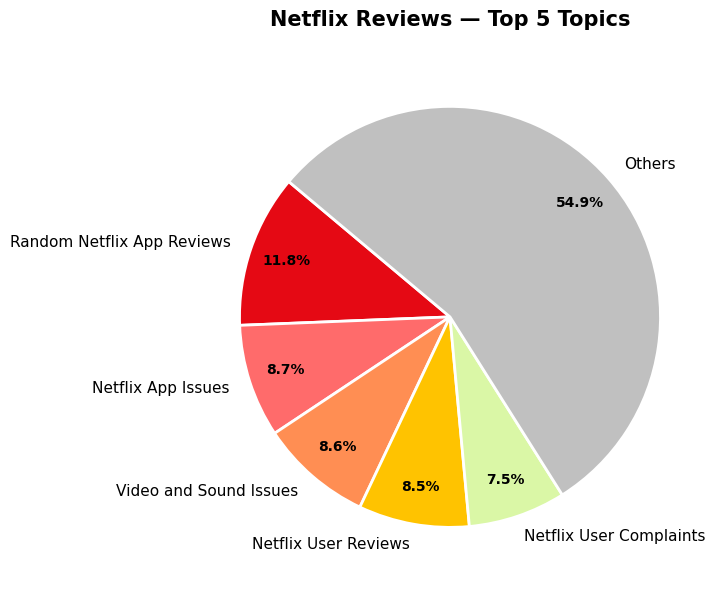

Saved to netflix_pie_chart.png


In [42]:
import matplotlib.pyplot as plt

# Get top 5 clusters by review count
top5 = summary_df.head(5)
others_count = summary_df.iloc[5:]['Review Count'].sum()
others_pct = summary_df.iloc[5:]['Percentage (%)'].sum()

# Build pie chart data
labels = top5['Topic'].tolist() + ['Others']
sizes = top5['Review Count'].tolist() + [others_count]
colors = ['#E50914', '#FF6B6B', '#FF8E53', '#FFC300', '#DAF7A6', '#C0C0C0']

fig, ax = plt.subplots(figsize=(9, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

# Style text
for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('black')

ax.set_title('Netflix Reviews — Top 5 Topics', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("netflix_pie_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to netflix_pie_chart.png")

In [45]:
def get_gaps_and_recommendations(cluster_id):
    samples = df[df['cluster_id'] == cluster_id]['content'].astype(str).sample(
        min(15, len(df[df['cluster_id'] == cluster_id]))
    ).tolist()
    sample_text = "\n---\n".join(samples)
    
    response = requests.post("http://localhost:11434/api/generate", json={
        "model": "llama3.2",
        "prompt": f"""You are a product manager analyzing Netflix app reviews.

Here are user reviews from the topic: "{cluster_labels[cluster_id]['topic']}"

Reviews:
{sample_text}

Based on these reviews, provide:
1. PRODUCT GAP: What is broken, missing, or frustrating users? (2-3 sentences)
2. RECOMMENDATION: What should the product team do to fix it? (2-3 actionable bullet points)

Respond ONLY in this format:
Product Gap: <your analysis>
Recommendations:
- <recommendation 1>
- <recommendation 2>
- <recommendation 3>""",
        "stream": False
    })
    
    return response.json()['response'].strip()

# Run only for negative/neutral clusters
actionable_clusters = summary_df[summary_df['Sentiment'].isin(['Negative', 'negative', 'Mixed', 'mixed', 'Neutral', 'neutral'])]

print("=" * 70)
print("NETFLIX APP - PRODUCT GAPS & RECOMMENDATIONS")
print("=" * 70)

gaps_data = []
for _, row in actionable_clusters.iterrows():
    cid = int(row['Cluster'])
    print(f"\nTOPIC: {row['Topic']}")
    print(f"Reviews: {row['Review Count']} ({row['Percentage (%)']}%) | Sentiment: {row['Sentiment']} | Confidence: {row['Confidence (%)']}%")
    print("-" * 70)
    
    analysis = get_gaps_and_recommendations(cid)
    print(analysis)
    print()
    
    # Parse for export
    lines = analysis.split("\n")
    gap = next((l.replace("Product Gap:", "").strip() for l in lines if l.startswith("Product Gap:")), "")
    recs = [l.strip("- ").strip() for l in lines if l.startswith("- ")]
    
    gaps_data.append({
        'Cluster': cid,
        'Topic': row['Topic'],
        'Sentiment': row['Sentiment'],
        'Review Count': row['Review Count'],
        'Percentage (%)': row['Percentage (%)'],
        'Confidence (%)': row['Confidence (%)'],
        'Product Gap': gap,
        'Recommendation 1': recs[0] if len(recs) > 0 else '',
        'Recommendation 2': recs[1] if len(recs) > 1 else '',
        'Recommendation 3': recs[2] if len(recs) > 2 else '',
    })

# Export to CSV
gaps_df = pd.DataFrame(gaps_data)
gaps_df.to_csv("netflix_product_gaps.csv", index=False)
print("=" * 70)
print("Saved to netflix_product_gaps.csv")

NETFLIX APP - PRODUCT GAPS & RECOMMENDATIONS

TOPIC: Random Netflix App Reviews
Reviews: 1175 (11.75%) | Sentiment: Mixed | Confidence: 52.56999969482422%
----------------------------------------------------------------------
Product Gap: The main issue is that users are experiencing inconsistencies with the app's pricing model, making it difficult for them to make informed decisions about their subscription. Some users feel that the price is too high or too low, while others express frustration about not having access to certain features or content (e.g., iwtv). This suggests a need for clarity and consistency in Netflix's pricing strategy.

Recommendations:
- Develop clear and transparent pricing information, including detailed breakdowns of costs associated with each plan.
- Implement a more flexible pricing model that allows users to adjust their subscription plans as needed, rather than being locked into a specific tier.
- Provide a clearer explanation of why certain features or c

In [49]:
import json
from IPython.display import display, HTML

# Generate the data array from gaps_df
js_data = []
for _, row in gaps_df.iterrows():
    js_data.append({
        "topic": row['Topic'],
        "sentiment": row['Sentiment'].lower(),
        "count": int(row['Review Count']),
        "pct": float(row['Percentage (%)']),
        "conf": float(row['Confidence (%)']),
        "gap": row['Product Gap'],
        "recs": [row['Recommendation 1'], row['Recommendation 2'], row['Recommendation 3']]
    })

html = """
<link href="https://fonts.googleapis.com/css2?family=DM+Sans:wght@400;500&family=Syne:wght@600;700&display=swap" rel="stylesheet"/>
<style>
  .nf-wrap *, .nf-wrap *::before, .nf-wrap *::after { box-sizing: border-box; margin: 0; padding: 0; }
  .nf-wrap { font-family: 'DM Sans', sans-serif; background: #f8f7f4; color: #1a1a18; padding: 2rem 1rem; border-radius: 12px; }
  .nf-container { max-width: 860px; margin: 0 auto; }
  .nf-header { display: flex; align-items: baseline; gap: 12px; margin-bottom: 1.5rem; border-bottom: 0.5px solid #e0ddd6; padding-bottom: 1rem; }
  .nf-header h1 { font-family: 'Syne', sans-serif; font-size: 22px; font-weight: 700; color: #1a1a18; letter-spacing: -0.3px; }
  .nf-header span { font-size: 12px; color: #888780; background: #efefeb; border: 0.5px solid #d3d1c7; border-radius: 20px; padding: 2px 10px; }
  .nf-filter-row { display: flex; gap: 8px; margin-bottom: 1.25rem; flex-wrap: wrap; }
  .nf-pill { font-size: 12px; padding: 4px 12px; border-radius: 20px; border: 0.5px solid #b4b2a9; background: transparent; color: #5f5e5a; cursor: pointer; transition: all .15s; font-family: 'DM Sans', sans-serif; }
  .nf-pill.active-neg { background: #FCEBEB; border-color: #E24B4A; color: #A32D2D; }
  .nf-pill.active-neu { background: #FAEEDA; border-color: #BA7517; color: #854F0B; }
  .nf-pill.active-all { background: #efefeb; border-color: #888780; color: #1a1a18; }
  .nf-grid { display: flex; flex-direction: column; gap: 12px; }
  .nf-card { background: #ffffff; border: 0.5px solid #e0ddd6; border-radius: 12px; padding: 1.1rem 1.25rem; transition: border-color .15s; }
  .nf-card:hover { border-color: #b4b2a9; }
  .nf-card-header { display: flex; align-items: flex-start; justify-content: space-between; gap: 12px; margin-bottom: 10px; }
  .nf-topic { font-family: 'Syne', sans-serif; font-size: 15px; font-weight: 600; color: #1a1a18; }
  .nf-badges { display: flex; gap: 6px; align-items: center; flex-shrink: 0; }
  .nf-badge { font-size: 11px; padding: 2px 9px; border-radius: 20px; font-weight: 500; white-space: nowrap; }
  .nf-badge-neg { background: #FCEBEB; color: #A32D2D; }
  .nf-badge-neu { background: #FAEEDA; color: #854F0B; }
  .nf-badge-count { background: #f1efe8; color: #5f5e5a; border: 0.5px solid #d3d1c7; }
  .nf-conf-row { display: flex; align-items: center; gap: 10px; margin-bottom: 12px; }
  .nf-conf-label { font-size: 11px; color: #888780; min-width: 68px; }
  .nf-conf-bar { flex: 1; height: 4px; background: #f1efe8; border-radius: 2px; overflow: hidden; }
  .nf-conf-fill { height: 100%; border-radius: 2px; }
  .nf-conf-val { font-size: 11px; color: #888780; min-width: 30px; text-align: right; }
  .nf-section-label { font-size: 11px; font-weight: 500; color: #888780; text-transform: uppercase; letter-spacing: 0.06em; margin-bottom: 5px; }
  .nf-gap-text { font-size: 13px; color: #5f5e5a; line-height: 1.6; margin-bottom: 12px; padding: 10px 12px; background: #f8f7f4; border-radius: 8px; border-left: 2px solid #E24B4A; }
  .nf-recs { display: flex; flex-direction: column; gap: 6px; }
  .nf-rec { display: flex; gap: 10px; align-items: flex-start; font-size: 13px; color: #1a1a18; line-height: 1.5; }
  .nf-rec-dot { width: 6px; height: 6px; border-radius: 50%; background: #3B8BD4; margin-top: 6px; flex-shrink: 0; }
  .nf-empty { text-align: center; padding: 2rem; color: #888780; font-size: 13px; }
</style>

<div class="nf-wrap">
  <div class="nf-container">
    <div class="nf-header">
      <h1>Netflix - Product Gaps</h1>
      <span id="nf-count-label"></span>
    </div>
    <div class="nf-filter-row">
      <button class="nf-pill active-all" onclick="nfFilter('all')">All topics</button>
      <button class="nf-pill" onclick="nfFilter('negative')">Negative</button>
      <button class="nf-pill" onclick="nfFilter('neutral')">Neutral / Mixed</button>
    </div>
    <div class="nf-grid" id="nf-grid"></div>
  </div>
</div>

<script>
const nfData = """ + json.dumps(js_data) + """;
let nfCurrent = 'all';

function nfFilter(f) {
  nfCurrent = f;
  document.querySelectorAll('.nf-pill').forEach(p => p.className = 'nf-pill');
  if (f === 'all') document.querySelectorAll('.nf-pill')[0].className = 'nf-pill active-all';
  else if (f === 'negative') document.querySelectorAll('.nf-pill')[1].className = 'nf-pill active-neg';
  else document.querySelectorAll('.nf-pill')[2].className = 'nf-pill active-neu';
  nfRender();
}

function nfRender() {
  const filtered = nfCurrent === 'all' ? nfData :
    nfData.filter(d => nfCurrent === 'negative' ? d.sentiment === 'negative' : d.sentiment !== 'negative');
  document.getElementById('nf-count-label').textContent = filtered.length + ' topics';
  const grid = document.getElementById('nf-grid');
  if (!filtered.length) {
    grid.innerHTML = '<div class="nf-empty">No topics match this filter.</div>';
    return;
  }
  grid.innerHTML = filtered.map(d => {
    const isNeg = d.sentiment === 'negative';
    const barColor = isNeg ? '#E24B4A' : '#BA7517';
    const recs = d.recs.filter(r => r && r.trim() !== '');
    return `
      <div class="nf-card">
        <div class="nf-card-header">
          <span class="nf-topic">${d.topic}</span>
          <div class="nf-badges">
            <span class="nf-badge ${isNeg ? 'nf-badge-neg' : 'nf-badge-neu'}">${isNeg ? 'Negative' : 'Neutral'}</span>
            <span class="nf-badge nf-badge-count">${d.count.toLocaleString()} reviews &middot; ${d.pct}%</span>
          </div>
        </div>
        <div class="nf-conf-row">
          <span class="nf-conf-label">Confidence</span>
          <div class="nf-conf-bar"><div class="nf-conf-fill" style="width:${d.conf}%;background:${barColor}"></div></div>
          <span class="nf-conf-val">${d.conf}%</span>
        </div>
        <div class="nf-section-label">Product gap</div>
        <div class="nf-gap-text">${d.gap}</div>
        <div class="nf-section-label">Recommendations</div>
        <div class="nf-recs">${recs.map(r => `<div class="nf-rec"><div class="nf-rec-dot"></div><span>${r}</span></div>`).join('')}</div>
      </div>`;
  }).join('');
}

nfRender();
</script>
"""

display(HTML(html))